In [1]:
print("START")

START


# FINAL REPORT 

# Customer Churn Exploratory Data Analysis (EDA) Report

The exploratory data analysis reveals several strong predictors of customer churn.
### Feature Engineering Opportunity

A new feature can be constructed:

**Total_Utility_Services**

This feature represents the total number of subscribed value-added services:

- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport

Customers with more subscribed utility services are expected to exhibit lower churn rates. This engineered feature may improve model performance by summarizing overall customer engagement.


### Strong Predictors

- Contract Type
- Tenure
- Internet Service
- Online Security
- Tech Support
- Online Backup
- Device Protection
- Payment Method
- Monthly Charges
- Total Charges
- Senior Citizen
- Partner
- Dependents

### Weak Predictors

- Gender
- Phone Service
- Multiple Lines
- Streaming TV
- Streaming Movies

### Business Recommendations

- Focus retention efforts on customers during their first five months.
- Encourage customers to transition from month-to-month contracts to longer-term agreements.
- Promote automatic payment methods instead of electronic checks.
- Bundle value-added services such as Online Security and Tech Support to improve customer retention.
- Closely monitor customers with high monthly bills, especially Fiber Optic subscribers, as they represent the highest-risk customer segment.


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import sklearn
import numpy as np 

In [56]:
data = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


I will drop the customerID column since it has nothing to do with the solution

In [57]:
data = data.drop("customerID", axis=1)

---

Let's turn the categorical feature into category data type.

In [58]:
categorical_columns = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

data[categorical_columns] = data[categorical_columns].astype("category")

In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   category
 1   SeniorCitizen     7043 non-null   category
 2   Partner           7043 non-null   category
 3   Dependents        7043 non-null   category
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   category
 6   MultipleLines     7043 non-null   category
 7   InternetService   7043 non-null   category
 8   OnlineSecurity    7043 non-null   category
 9   OnlineBackup      7043 non-null   category
 10  DeviceProtection  7043 non-null   category
 11  TechSupport       7043 non-null   category
 12  StreamingTV       7043 non-null   category
 13  StreamingMovies   7043 non-null   category
 14  Contract          7043 non-null   category
 15  PaperlessBilling  7043 non-null   category
 16  PaymentMethod     7043 n

---

Let's turn the `TotalCharges` feature into float type. Since its datatype is a string

In [60]:
data["TotalCharges"] = data["TotalCharges"].astype("float")

ValueError: could not convert string to float: ' '

In [61]:
data[data["TotalCharges"] == " "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [62]:
len(data[data["TotalCharges"] == " "])

11

The customers who is with the company for 0 month (tenure == 0) , their totalCharges is null, so to turn the TotalCharges into float data type, first we must fill these null rows, with 0 since they did not pay yet.

In [63]:
data["TotalCharges"] = data["TotalCharges"].replace(" ", value="0.0")

In [64]:
data[data["tenure"] == 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


Let's convert now!

In [65]:
data["TotalCharges"] = data["TotalCharges"].astype("float")

In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   category
 1   SeniorCitizen     7043 non-null   category
 2   Partner           7043 non-null   category
 3   Dependents        7043 non-null   category
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   category
 6   MultipleLines     7043 non-null   category
 7   InternetService   7043 non-null   category
 8   OnlineSecurity    7043 non-null   category
 9   OnlineBackup      7043 non-null   category
 10  DeviceProtection  7043 non-null   category
 11  TechSupport       7043 non-null   category
 12  StreamingTV       7043 non-null   category
 13  StreamingMovies   7043 non-null   category
 14  Contract          7043 non-null   category
 15  PaperlessBilling  7043 non-null   category
 16  PaymentMethod     7043 n

---

Let's see, is there any missing feature

In [67]:
data.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

No

---

Before, move on to the feature engineering step, we must split the data into training and test set because we should treat the test set as unseen data, therefore we can't use it for feature engineering or selection purposes, if we did it, test set was seen during the machine learning model creation pipeline, it leds the model to fail to generalize the uncoming data and bad evaluation metrics. 

In [68]:
from sklearn.model_selection import train_test_split

X = data.drop("Churn", axis=1)
y = data["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                   y,
                                                   test_size=0.2,
                                                   random_state=42,
                                                   stratify=y)

In [69]:
y_train.value_counts()

Churn
No     4139
Yes    1495
Name: count, dtype: int64

In [70]:
y_test.value_counts()

Churn
No     1035
Yes     374
Name: count, dtype: int64

In [71]:
y_train[:5], y_test[:5]

(3738    No
 3151    No
 4860    No
 3867    No
 3810    No
 Name: Churn, dtype: object,
 437     No
 2280    No
 2235    No
 4460    No
 3761    No
 Name: Churn, dtype: object)

It is an imbalanced data, we see

---

## Feature Engineering 

In [72]:
X_train.head().T

,3738,3151,4860,3867,3810
gender,Male,Male,Male,Female,Male
SeniorCitizen,0,0,0,0,0
Partner,No,Yes,Yes,Yes,Yes
Dependents,No,Yes,Yes,No,Yes
tenure,35,15,13,26,1
PhoneService,No,Yes,No,Yes,Yes
MultipleLines,No phone service,No,No phone service,No,No
InternetService,DSL,Fiber optic,DSL,DSL,DSL
OnlineSecurity,No,Yes,Yes,No,No
OnlineBackup,No,No,Yes,Yes,No


I will create `service_count` feature by summing up all of the service features.

In [73]:
X_train["PhoneService"].value_counts()

PhoneService
Yes    5075
No      559
Name: count, dtype: int64

In [74]:
service_features = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

for feature in service_features: 
    print(feature)
    print(X_train[feature].value_counts().index.unique().categories)
    print()

PhoneService
Index(['No', 'Yes'], dtype='object')

MultipleLines
Index(['No', 'No phone service', 'Yes'], dtype='object')

InternetService
Index(['DSL', 'Fiber optic', 'No'], dtype='object')

OnlineSecurity
Index(['No', 'No internet service', 'Yes'], dtype='object')

OnlineBackup
Index(['No', 'No internet service', 'Yes'], dtype='object')

DeviceProtection
Index(['No', 'No internet service', 'Yes'], dtype='object')

TechSupport
Index(['No', 'No internet service', 'Yes'], dtype='object')

StreamingTV
Index(['No', 'No internet service', 'Yes'], dtype='object')

StreamingMovies
Index(['No', 'No internet service', 'Yes'], dtype='object')



In [75]:
active_values = {"Yes", "DSL", "Fiber optic"}

X_train["service_count"] = (
    X_train[service_features]
    .isin(active_values)
    .sum(axis=1)
)

In [76]:
X_train.head().T

,3738,3151,4860,3867,3810
gender,Male,Male,Male,Female,Male
SeniorCitizen,0,0,0,0,0
Partner,No,Yes,Yes,Yes,Yes
Dependents,No,Yes,Yes,No,Yes
tenure,35,15,13,26,1
PhoneService,No,Yes,No,Yes,Yes
MultipleLines,No phone service,No,No phone service,No,No
InternetService,DSL,Fiber optic,DSL,DSL,DSL
OnlineSecurity,No,Yes,Yes,No,No
OnlineBackup,No,No,Yes,Yes,No


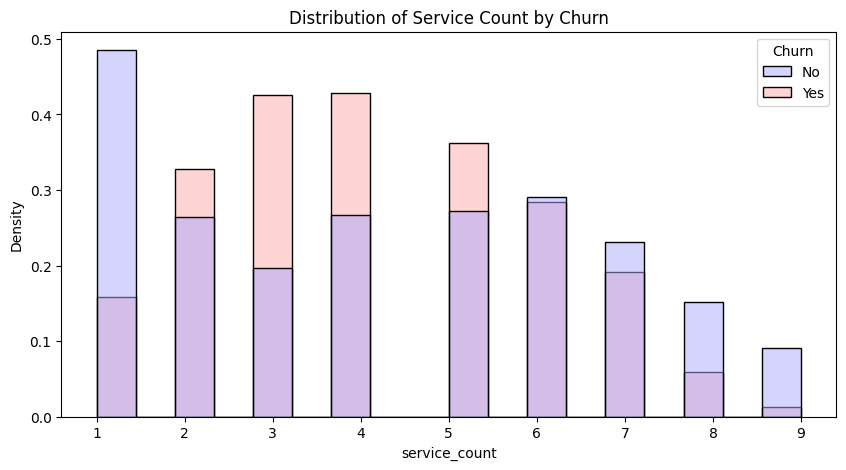

In [77]:
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    data=X_train,
    x="service_count",
    hue=y_train,
    multiple="layer",
    stat="density",
    common_norm=False,
    palette="bwr"
)

plt.title("Distribution of Service Count by Churn")
plt.show()

/tmp/ipykernel_104716/3190047755.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


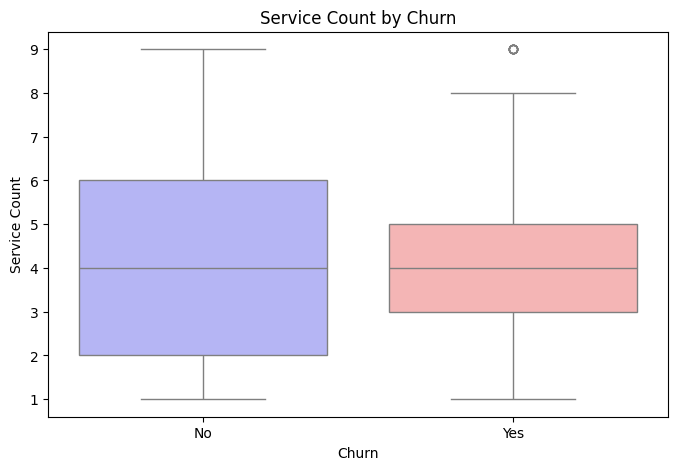

In [78]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=y_train,
    y=X_train["service_count"],
    palette="bwr"
)

plt.xlabel("Churn")
plt.ylabel("Service Count")
plt.title("Service Count by Churn")
plt.show()

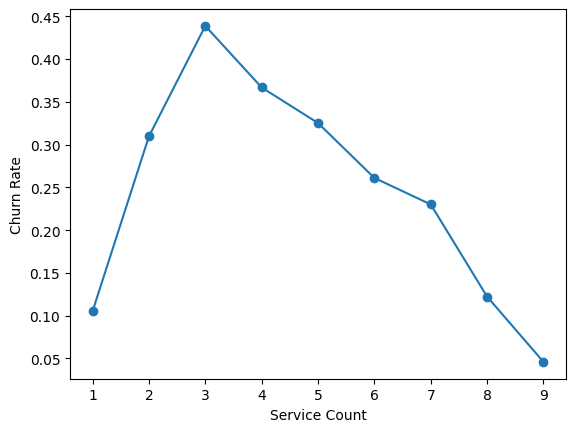

service_count
1    0.105210
2    0.309659
3    0.438760
4    0.366795
5    0.325236
6    0.261050
7    0.230072
8    0.122257
9    0.045977
Name: Churn, dtype: float64


In [79]:
temp = X_train.copy()
temp["Churn"] = y_train.map({"No": 0, "Yes": 1})

service_churn = (
    temp.groupby("service_count")["Churn"]
        .mean()
)

service_churn.plot(marker="o")
plt.ylabel("Churn Rate")
plt.xlabel("Service Count")
plt.show()

print(service_churn)

The Peak (Highest Risk): The churn rate peaks significantly at 3 services, reaching nearly 44%. Users with exactly 2 or 3 services are at the highest risk of churning.

The Sweet Spot (Highest Retention): As the service count increases beyond 3, the churn rate drops consistently. It reaches its lowest point at 9 services (under 5%).

Low Service Exception: Interestingly, users with only 1 service have a relatively low churn rate (~10%) compared to those with 2 or 3 services.

---

### Feature Engineering: Gender × Senior Citizen Interaction

We will investigate whether combining the `Gender` and `SeniorCitizen` features into a new interaction feature (`gender_senior`) provides additional predictive information.

From the EDA, we observed that **Gender** alone shows little association with the target variable (`Churn`), while **SeniorCitizen** exhibits a stronger relationship, with senior customers having a higher churn rate than non-senior customers.

Although Gender appears to have limited predictive value on its own, it is possible that its interaction with SeniorCitizen reveals patterns that are not visible when each feature is analyzed independently. To evaluate this hypothesis, we create the `gender_senior` feature (e.g., `Female_NonSenior`, `Male_Senior`) and compare the churn rates across these groups.

If the interaction feature reveals meaningful differences between the groups, it may provide additional information to the model. Otherwise, the feature will be discarded to avoid introducing unnecessary complexity.


In [80]:
X_train.head().T

,3738,3151,4860,3867,3810
gender,Male,Male,Male,Female,Male
SeniorCitizen,0,0,0,0,0
Partner,No,Yes,Yes,Yes,Yes
Dependents,No,Yes,Yes,No,Yes
tenure,35,15,13,26,1
PhoneService,No,Yes,No,Yes,Yes
MultipleLines,No phone service,No,No phone service,No,No
InternetService,DSL,Fiber optic,DSL,DSL,DSL
OnlineSecurity,No,Yes,Yes,No,No
OnlineBackup,No,No,Yes,Yes,No


In [81]:
pd.crosstab([X_train["gender"], X_train["SeniorCitizen"]], y_train, normalize="index")

Churn                       No       Yes
gender SeniorCitizen                    
Female 0              0.761378  0.238622
       1              0.588889  0.411111
Male   0              0.764706  0.235294
       1              0.589362  0.410638

In [82]:
(
    X_train.assign(Churn=y_train)
    .groupby(["gender", "SeniorCitizen"])["Churn"]
    .value_counts(normalize=True) * 100
)

/tmp/ipykernel_104716/66504825.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["gender", "SeniorCitizen"])["Churn"]


gender  SeniorCitizen  Churn
Female  0              No       76.137814
                       Yes      23.862186
        1              No       58.888889
                       Yes      41.111111
Male    0              No       76.470588
                       Yes      23.529412
        1              No       58.936170
                       Yes      41.063830
Name: proportion, dtype: float64

In [83]:
X_train["gender_senior"] = (
    X_train["gender"].astype(str)
    + "_"
    + X_train["SeniorCitizen"].astype(int).map({0: "NonSenior", 1: "Senior"})
)

<Axes: xlabel='gender_senior', ylabel='percentage'>

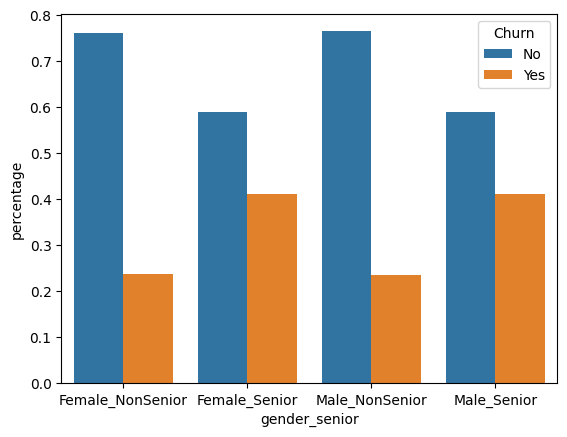

In [84]:
temp = X_train.copy()
temp["Churn"] = y_train


df_perc = temp.groupby(['gender_senior'])['Churn'].value_counts(normalize=True).rename('percentage').reset_index()
sns.barplot(data=df_perc, x='gender_senior', y='percentage', hue='Churn')


We can clearly see that interacting the `Gender` and `SeniorCitizen` features does not provide any valuable information, since we already know that non-senior customers are less likely to churn. Adding `Gender` to `SeniorCitizen` does not create a valuable feature for the model.


Let's drop the column then.

In [85]:
X_train = X_train.drop("gender_senior", axis=1)

In [86]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'service_count'],
      dtype='object')

---

Let's create a feature `service_per_month` by using tenure and service_coutn features

In [87]:
X_train.head().T

,3738,3151,4860,3867,3810
gender,Male,Male,Male,Female,Male
SeniorCitizen,0,0,0,0,0
Partner,No,Yes,Yes,Yes,Yes
Dependents,No,Yes,Yes,No,Yes
tenure,35,15,13,26,1
PhoneService,No,Yes,No,Yes,Yes
MultipleLines,No phone service,No,No phone service,No,No
InternetService,DSL,Fiber optic,DSL,DSL,DSL
OnlineSecurity,No,Yes,Yes,No,No
OnlineBackup,No,No,Yes,Yes,No


In [88]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'service_count'],
      dtype='object')

In [89]:
X_train["services_per_month"] = (
    X_train["service_count"] / X_train["tenure"].replace(0, 1)
)

In [90]:
X_train.head().T

,3738,3151,4860,3867,3810
gender,Male,Male,Male,Female,Male
SeniorCitizen,0,0,0,0,0
Partner,No,Yes,Yes,Yes,Yes
Dependents,No,Yes,Yes,No,Yes
tenure,35,15,13,26,1
PhoneService,No,Yes,No,Yes,Yes
MultipleLines,No phone service,No,No phone service,No,No
InternetService,DSL,Fiber optic,DSL,DSL,DSL
OnlineSecurity,No,Yes,Yes,No,No
OnlineBackup,No,No,Yes,Yes,No


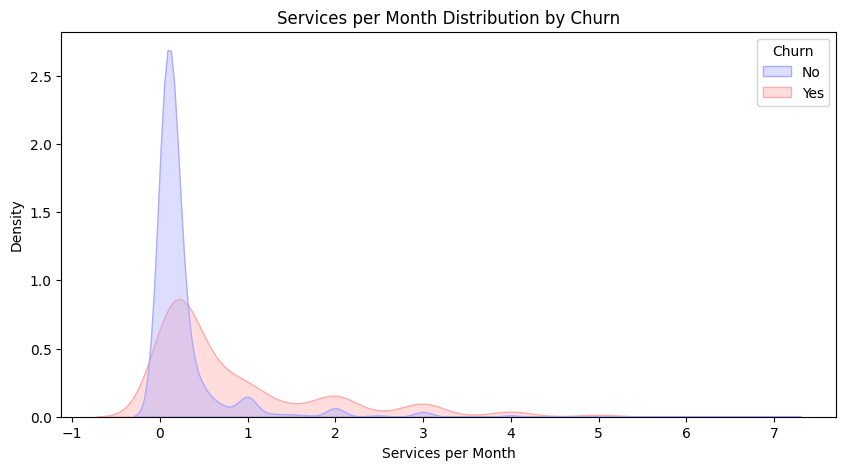

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

temp = X_train.copy()
temp["Churn"] = y_train

plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=temp,
    x="services_per_month",
    hue="Churn",
    fill=True,
    common_norm=False,
    alpha=0.4,
    palette="bwr"
)

plt.title("Services per Month Distribution by Churn")
plt.xlabel("Services per Month")
plt.ylabel("Density")
plt.show()

/tmp/ipykernel_104716/4140940851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


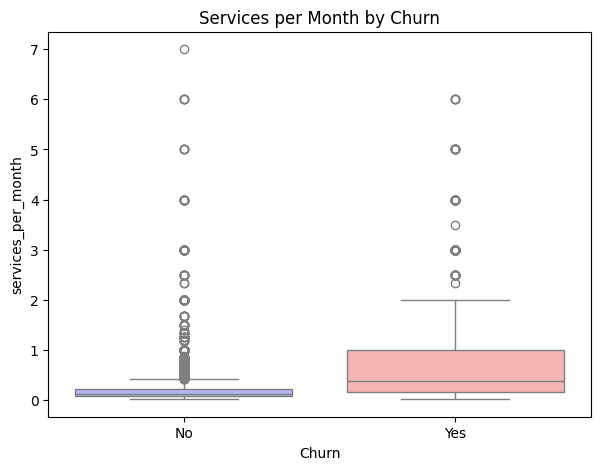

In [92]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=temp,
    x="Churn",
    y="services_per_month",
    palette="bwr"
)

plt.title("Services per Month by Churn")
plt.show()

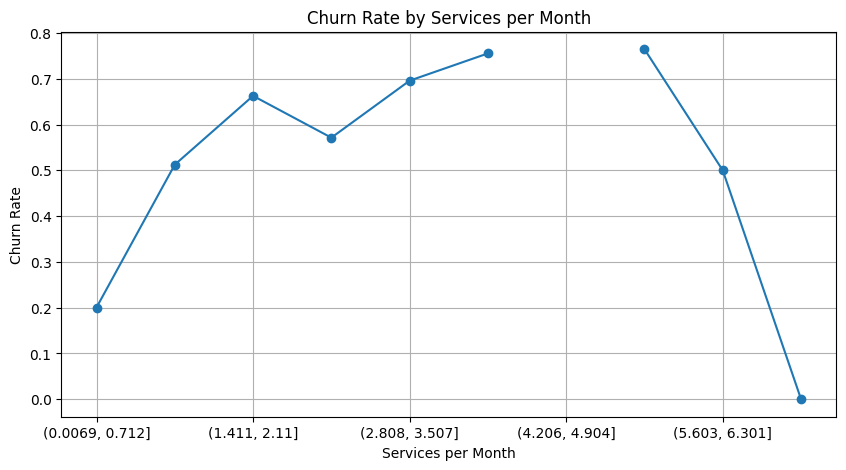

spm_bin
(0.0069, 0.712]    0.200382
(0.712, 1.411]     0.512472
(1.411, 2.11]      0.662791
(2.11, 2.808]      0.571429
(2.808, 3.507]     0.696000
(3.507, 4.206]     0.755556
(4.206, 4.904]          NaN
(4.904, 5.603]     0.764706
(5.603, 6.301]     0.500000
(6.301, 7.0]       0.000000
Name: Churn, dtype: float64

In [93]:
temp = X_train.copy()
temp["Churn"] = y_train.map({"No": 0, "Yes": 1})

temp["spm_bin"] = pd.cut(
    temp["services_per_month"],
    bins=10
)

churn_rate = (
    temp.groupby("spm_bin", observed=False)["Churn"]
        .mean()
)

plt.figure(figsize=(10, 5))
churn_rate.plot(marker="o")

plt.ylabel("Churn Rate")
plt.xlabel("Services per Month")
plt.title("Churn Rate by Services per Month")
plt.grid(True)
plt.show()

churn_rate

Let's keep this feature to see whether it has an effect when we train the models

In [94]:
X_train.head().T

,3738,3151,4860,3867,3810
gender,Male,Male,Male,Female,Male
SeniorCitizen,0,0,0,0,0
Partner,No,Yes,Yes,Yes,Yes
Dependents,No,Yes,Yes,No,Yes
tenure,35,15,13,26,1
PhoneService,No,Yes,No,Yes,Yes
MultipleLines,No phone service,No,No phone service,No,No
InternetService,DSL,Fiber optic,DSL,DSL,DSL
OnlineSecurity,No,Yes,Yes,No,No
OnlineBackup,No,No,Yes,Yes,No


In [112]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'service_count',
       'services_per_month'],
      dtype='object')

# Training the models with new features

In [95]:
# Data processing
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from imblearn.ensemble import BalancedRandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [96]:
categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]


numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "service_count",
    "services_per_month"
]

In [97]:
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


numeric_transformer = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [98]:
models = {

    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric="logloss",
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        verbose=0,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "BalancedRandomForest": BalancedRandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

In [99]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

First let's implement new engineered features to the X_test by creating a function

In [114]:
def create_features(df):

    df = df.copy()

    service_features = [
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
    ]

    active_values = {"Yes", "DSL", "Fiber optic"}

    df["service_count"] = (
        df[service_features]
        .isin(active_values)
        .sum(axis=1)
    )

    df["services_per_month"] = (
        df["service_count"] /
        df["tenure"].replace(0, 1)
    )

    return df

In [101]:
X_train = create_features(X_train)
X_test = create_features(X_test)

X_train.head().T

,3738,3151,4860,3867,3810
gender,Male,Male,Male,Female,Male
SeniorCitizen,0,0,0,0,0
Partner,No,Yes,Yes,Yes,Yes
Dependents,No,Yes,Yes,No,Yes
tenure,35,15,13,26,1
PhoneService,No,Yes,No,Yes,Yes
MultipleLines,No phone service,No,No phone service,No,No
InternetService,DSL,Fiber optic,DSL,DSL,DSL
OnlineSecurity,No,Yes,Yes,No,No
OnlineBackup,No,No,Yes,Yes,No


In [102]:
X_test.head().T

,437,2280,2235,4460,3761
gender,Male,Female,Female,Male,Female
SeniorCitizen,0,1,0,0,0
Partner,Yes,No,Yes,Yes,Yes
Dependents,Yes,No,Yes,No,No
tenure,72,8,41,18,72
PhoneService,Yes,Yes,Yes,Yes,Yes
MultipleLines,Yes,Yes,Yes,No,Yes
InternetService,Fiber optic,Fiber optic,DSL,Fiber optic,DSL
OnlineSecurity,Yes,No,Yes,No,Yes
OnlineBackup,Yes,No,Yes,No,Yes


In [103]:
print(X_train.shape)
print(X_test.shape)

print(set(X_train.columns) - set(X_test.columns))

(5634, 21)
(1409, 21)
set()


Let's turn the target variable into integer 0, 1 instead of `Yes`, `No`.

In [104]:
y_train[:5], y_test[:5]

(3738    No
 3151    No
 4860    No
 3867    No
 3810    No
 Name: Churn, dtype: object,
 437     No
 2280    No
 2235    No
 4460    No
 3761    No
 Name: Churn, dtype: object)

In [105]:
print(y_train.unique())
print(y_train.dtype)

['No' 'Yes']
object


In [106]:
print(y_train.dtype)
print(type(y_train.iloc[0]))

object
<class 'str'>


In [109]:
y_train = y_train.replace({"No": 0, "Yes": 1})
y_test = y_test.replace({"No": 0, "Yes": 1})

y_train[:10], y_test[:10]

(3738    0
 3151    0
 4860    0
 3867    0
 3810    0
 2666    0
 2645    0
 189     0
 5767    0
 2257    0
 Name: Churn, dtype: int64,
 437     0
 2280    0
 2235    0
 4460    0
 3761    0
 5748    0
 3568    0
 2976    0
 5928    0
 1639    1
 Name: Churn, dtype: int64)

In [111]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd


def evaluate_models(
    pipelines,
    X_train,
    X_test,
    y_train,
    y_test,
    n_splits=5,
    random_state=42
):
    """
    Train and evaluate multiple classification pipelines.

    Returns:
        DataFrame containing test and cross-validation metrics.
    """

    results = []

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    for name, pipeline in pipelines.items():

        print(f"Training {name}...")

        # Train model
        pipeline.fit(
            X_train,
            y_train
        )

        # Test predictions
        y_pred = pipeline.predict(X_test)

        if hasattr(pipeline, "predict_proba"):
            y_prob = pipeline.predict_proba(X_test)[:, 1]
        else:
            y_prob = None


        # Test metrics
        result = {
            "Model": name,

            "Test Accuracy": accuracy_score(
                y_test,
                y_pred
            ),

            "Test Precision": precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),

            "Test Recall": recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),

            "Test F1": f1_score(
                y_test,
                y_pred,
                zero_division=0
            )
        }


        if y_prob is not None:
            result["Test ROC-AUC"] = roc_auc_score(
                y_test,
                y_prob
            )


        # Cross validation
        cv_scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=[
                "roc_auc",
                "precision",
                "recall",
                "f1"
            ],
            n_jobs=-1
        )


        result["CV ROC-AUC Mean"] = (
            cv_scores["test_roc_auc"].mean()
        )

        result["CV ROC-AUC Std"] = (
            cv_scores["test_roc_auc"].std()
        )

        result["CV Precision Mean"] = (
            cv_scores["test_precision"].mean()
        )

        result["CV Recall Mean"] = (
            cv_scores["test_recall"].mean()
        )

        result["CV F1 Mean"] = (
            cv_scores["test_f1"].mean()
        )


        results.append(result)


    results_df = pd.DataFrame(results)

    return results_df.sort_values(
        by="CV ROC-AUC Mean",
        ascending=False
    )
    
results_df = evaluate_models(
    pipelines=pipelines,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

results_df

Training LogisticRegression...
Training KNN...
Training RandomForest...
Training XGBoost...
Training CatBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000160 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 903
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


/home/tuana/Telecom-Churn-Prediction-system/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tuana/Telecom-Churn-Prediction-system/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tuana/Telecom-Churn-Prediction-system/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tuana/Telecom-Churn-Prediction-system/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tuana/Telecom-Churn-Prediction-system/.venv/lib/python3.10/site-packages/sklea

Training BalancedRandomForest...


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,CV ROC-AUC Mean,CV ROC-AUC Std,CV Precision Mean,CV Recall Mean,CV F1 Mean
0,LogisticRegression,0.737402,0.503436,0.783422,0.612971,0.847291,0.848099,0.011361,0.523498,0.797993,0.632090
4,CatBoost,0.799148,0.651163,0.524064,0.580741,0.842884,0.844387,0.009526,0.667147,0.519064,0.583644
3,XGBoost,0.789922,0.625000,0.521390,0.568513,0.834347,0.837825,0.008698,0.647551,0.519732,0.576461
6,BalancedRandomForest,0.767921,0.548454,0.711230,0.619325,0.834808,0.834834,0.010412,0.549568,0.704348,0.617214
5,LightGBM,0.796309,0.637224,0.540107,0.584660,0.831387,0.834122,0.008994,0.635144,0.511706,0.566648
2,RandomForest,0.782115,0.617544,0.470588,0.534143,0.827858,0.825685,0.010575,0.637170,0.471572,0.541831
1,KNN,0.766501,0.561983,0.545455,0.553596,0.780220,0.783493,0.008143,0.574584,0.530435,0.551482


[LightGBM] [Info] Number of positive: 1196, number of negative: 3312
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.136990 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 904
[LightGBM] [Info] Number of data points in the train set: 4508, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265306 -> initscore=-1.018570
[LightGBM] [Info] Start training from score -1.018570
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.099999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 904
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 48
[LightGBM] [Info] [binary:

---

In [123]:
lr = pipelines["LogisticRegression"]
feature_names = (
    lr.named_steps["preprocessor"]
    .get_feature_names_out()
)
coef = lr.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": coef
})

importance.sort_values(
    "importance",
    key=abs,
    ascending=False
).head(20)

,feature,importance
41,cat__Contract_Two year,-0.864411
0,num__tenure,-0.817750
1,num__MonthlyCharges,-0.802565
19,cat__InternetService_Fiber optic,0.768643
39,cat__Contract_Month-to-month,0.726355
18,cat__InternetService_DSL,-0.709541
2,num__TotalCharges,0.368590
4,num__services_per_month,0.319934
3,num__service_count,0.308399
42,cat__PaperlessBilling_No,-0.251702


Let's select the 3 best model and do GridSearchCV on them

In [154]:
selected_models = {
    "LogisticRegression": pipelines["LogisticRegression"],
    "CatBoost": pipelines["CatBoost"],
    "BalancedRandomForest": pipelines["BalancedRandomForest"]
}

In [155]:
selected_param_grids = {

    "LogisticRegression": {

        "model__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],

        "model__class_weight": [
            None,
            "balanced"
        ]
    },


    "CatBoost": {

        "model__iterations": [
            200,
            300,
            500
        ],

        "model__depth": [
            4,
            5,
            6,
            7
        ],

        "model__learning_rate": [
            0.01,
            0.05,
            0.1
        ]
    },


    "BalancedRandomForest": {

        "model__n_estimators": [
            200,
            300,
            500
        ],

        "model__max_depth": [
            None,
            5,
            10,
            20
        ],

        "model__min_samples_leaf": [
            1,
            2,
            5
        ]
    }

}

In [161]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd


def grid_search_models(
    pipelines,
    param_grids,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    random_state=42
):
    """
    Perform GridSearchCV for multiple classification pipelines.

    Returns:
        results_df: CV metrics and best parameters
        best_models: fitted best estimators
    """

    results = []
    best_models = {}


    cv_strategy = StratifiedKFold(
        n_splits=cv,
        shuffle=True,
        random_state=random_state
    )


    for name, pipeline in pipelines.items():

        print(f"\nGrid searching {name}...")


        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            scoring={
                "roc_auc": "roc_auc",
                "precision": "precision",
                "recall": "recall",
                "f1": "f1"
            },
            refit="roc_auc",
            cv=cv_strategy,
            n_jobs=-1,
            verbose=1
        )


        grid_search.fit(
            X_train,
            y_train
        )


        best_models[name] = grid_search.best_estimator_


        best_index = grid_search.best_index_


        results.append({

            "Model": name,

            "CV ROC-AUC Mean": grid_search.cv_results_[
                "mean_test_roc_auc"
            ][best_index],

            "CV ROC-AUC Std": grid_search.cv_results_[
                "std_test_roc_auc"
            ][best_index],


            "CV Precision Mean": grid_search.cv_results_[
                "mean_test_precision"
            ][best_index],


            "CV Recall Mean": grid_search.cv_results_[
                "mean_test_recall"
            ][best_index],


            "CV F1 Mean": grid_search.cv_results_[
                "mean_test_f1"
            ][best_index],


            "Best Parameters": grid_search.best_params_

        })


        print(
            f"{name} best ROC-AUC: "
            f"{grid_search.best_score_:.4f}"
        )


    results_df = (
        pd.DataFrame(results)
        .sort_values(
            by="CV ROC-AUC Mean",
            ascending=False
        )
    )


    return results_df, best_models

In [162]:
grid_results, best_models = grid_search_models(
    selected_models,
    selected_param_grids,
    X_train,
    y_train
)


Grid searching LogisticRegression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
LogisticRegression best ROC-AUC: 0.8485

Grid searching CatBoost...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
CatBoost best ROC-AUC: 0.8503

Grid searching BalancedRandomForest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
BalancedRandomForest best ROC-AUC: 0.8475


In [163]:
grid_results

,Model,CV ROC-AUC Mean,CV ROC-AUC Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,Best Parameters
1,CatBoost,0.850285,0.011495,0.676529,0.519732,0.587720,"{'model__depth': 5, 'model__iterations': 500, ..."
0,LogisticRegression,0.848523,0.011694,0.662613,0.545819,0.597526,"{'model__C': 100, 'model__class_weight': None}"
2,BalancedRandomForest,0.847519,0.010549,0.529919,0.767224,0.626645,"{'model__max_depth': 10, 'model__min_samples_l..."


Let's tune the threshold

In [164]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd


def evaluate_thresholds(
    pipelines,
    X_train,
    X_test,
    y_train,
    y_test,
    thresholds=None
):
    """
    Evaluate classification models with different probability thresholds.

    Returns:
        DataFrame containing metrics for each model and threshold.
    """

    if thresholds is None:
        thresholds = [
            0.3,
            0.35,
            0.4,
            0.45,
            0.5,
            0.55,
            0.6
        ]

    results = []


    for name, pipeline in pipelines.items():


        y_prob = pipeline.predict_proba(X_test)[:, 1]


        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )


        for threshold in thresholds:

            y_pred = (
                y_prob >= threshold
            ).astype(int)


            result = {
                "Model": name,
                "Threshold": threshold,

                "Accuracy": accuracy_score(
                    y_test,
                    y_pred
                ),

                "Precision": precision_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),

                "Recall": recall_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),

                "F1": f1_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),

                "ROC-AUC": roc_auc
            }


            results.append(result)


    return (
        pd.DataFrame(results)
        .sort_values(
            by="F1",
            ascending=False
        )
    )

In [165]:
threshold_results = evaluate_thresholds(
    best_models,
    X_train,
    X_test,
    y_train,
    y_test
)

In [166]:
threshold_results.sort_values(by="F1", ascending=False)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
18,BalancedRandomForest,0.50,0.760823,0.533095,0.796791,0.638800,0.845462
19,BalancedRandomForest,0.55,0.772889,0.554000,0.740642,0.633867,0.845462
8,CatBoost,0.35,0.778566,0.565401,0.716578,0.632075,0.845558
7,CatBoost,0.30,0.758694,0.531250,0.772727,0.629630,0.845558
0,LogisticRegression,0.30,0.760823,0.534709,0.762032,0.628445,0.846157
20,BalancedRandomForest,0.60,0.785664,0.582569,0.679144,0.627160,0.845462
17,BalancedRandomForest,0.45,0.738112,0.504078,0.826203,0.626140,0.845462
1,LogisticRegression,0.35,0.770050,0.551867,0.711230,0.621495,0.846157
9,CatBoost,0.40,0.787793,0.591241,0.649733,0.619108,0.845558
2,LogisticRegression,0.40,0.778566,0.571101,0.665775,0.614815,0.846157


---

# Final Model Selection

After hyperparameter tuning, the model with the best overall performance was selected as **BalancedRandomForest** with the following metrics:

- **Accuracy**: 0.76
- **Precision**: 0.53
- **Recall**: 0.80
- **F1-score**: 0.64
- **ROC-AUC**: 0.85
- **Threshold**: 0.50

The model is able to identify approximately **80% of customers who actually churn**. This means that out of 100 customers who are going to leave, the model can detect around 80 of them.

The model's precision is **53%**, meaning that among the customers predicted as churners, approximately 53 out of 100 customers are actually going to churn.

The selected model prioritizes identifying potential churn customers while maintaining a reasonable balance between false positives and false negatives. Since missing a customer who is likely to churn can result in losing potential revenue, achieving a high recall was considered important for this problem.

The final classification threshold was adjusted to improve the precision-recall trade-off.

## Saving the model parameters

In [181]:
params = best_models["BalancedRandomForest"].named_steps["model"].get_params
params

<bound method BaseEstimator.get_params of BalancedRandomForestClassifier(max_depth=10, min_samples_leaf=5,
                               n_estimators=500, n_jobs=-1, random_state=42)>

In [183]:
import yaml

best_params = {
    "model": "BalancedRandomForest",
    "parameters": {
        "n_estimators": 500,
        "max_depth": 10,
        "min_samples_leaf": 5,
        "random_state": 42,
        "n_jobs": -1
    },
    "threshold": 0.50
}


with open(
    "../configs/model/baseline.yaml",
    "w"
) as f:
    yaml.dump(
        best_params,
        f,
        sort_keys=False
    )

In [184]:
print("END")

END
